In [1]:
import scanpy as sc
import numpy as np

In [2]:
gf = sc.read_h5ad("mouse_geneformer_embedded.h5ad")
sc.pp.log1p(gf)
gf

/home/mccwen/.local/lib/python3.11/site-packages/scanpy/preprocessing/_simple.py:383: RuntimeWarning: invalid value encountered in log1p
  np.log1p(X, out=X)


AnnData object with n_obs × n_vars = 3365 × 512
    obs: 'cell_type', 'n_counts'
    uns: 'log1p'

In [3]:
# 1. Remove NaNs
gf.X = np.nan_to_num(gf.X, nan=0)

# 2. Scale the data (zero-mean, unit-variance)
sc.pp.scale(gf, max_value=10)

# 3. PCA
sc.tl.pca(gf, svd_solver='arpack')

# 4. Compute neighborhood graph
sc.pp.neighbors(gf, n_neighbors=15, n_pcs=50)

# 5. UMAP
sc.tl.umap(gf)
gf

2025-04-30 21:31:36.323571: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746063096.561484  640666 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746063096.626815  640666 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1746063097.221922  640666 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1746063097.221941  640666 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1746063097.221942  640666 computation_placer.cc:177] computation placer alr

AnnData object with n_obs × n_vars = 3365 × 512
    obs: 'cell_type', 'n_counts'
    var: 'mean', 'std'
    uns: 'log1p', 'pca', 'neighbors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

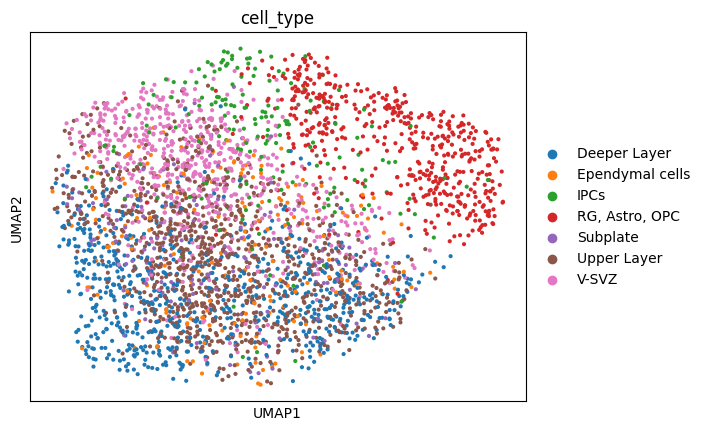

In [6]:
# Show embedded space on UMAP
sc.pl.umap(gf, color="cell_type", save= "Geneformer_generated_mouse_embedding_umap.svg")

## Split embedded data into training, testing and validation sets

In [23]:
from sklearn.model_selection import train_test_split

In [25]:
gf.to_df()

var_names,D0,D1,D2,D3,D4,D5,D6,D7,D8,D9,...,D502,D503,D504,D505,D506,D507,D508,D509,D510,D511
0,0.090007,0.0,-0.360330,-1.382581,0.168285,-0.652668,0.0,-0.440005,-0.683805,-0.302319,...,0.654001,0.0,0.265221,0.0,0.708869,1.006415,0.235049,0.0,-0.437658,-0.519941
1,1.736952,0.0,-0.258482,0.849051,-0.099036,-0.614231,0.0,-4.112129,-0.207497,-1.630717,...,0.166712,0.0,-2.585627,0.0,0.662831,0.736435,0.040325,0.0,-0.992994,-0.038981
2,0.150718,0.0,-0.664066,1.126690,-0.788826,0.767520,0.0,0.199141,-0.095319,0.346357,...,0.160981,0.0,-0.507413,0.0,0.263247,-0.097375,0.457351,0.0,0.218121,-0.184965
3,0.356023,0.0,1.293727,0.531970,-0.006701,1.250348,0.0,-0.634704,-0.224183,-0.341293,...,0.088731,0.0,0.496177,0.0,0.948866,-0.823557,1.442229,0.0,-0.287861,0.311438
4,-0.636801,0.0,-0.932430,-0.794392,-2.108646,0.084405,0.0,0.326981,-1.219210,-0.215838,...,0.000663,0.0,-0.815706,0.0,-0.527220,0.787422,1.417557,0.0,0.805435,-0.611844
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3360,-0.899062,0.0,1.489833,0.949128,0.121859,-0.294956,0.0,1.267355,-1.587751,0.435688,...,-1.370372,0.0,-1.145776,0.0,-0.357751,0.042140,0.503067,0.0,1.228582,0.569911
3361,-0.320079,0.0,-0.113574,0.303162,1.257545,1.151506,0.0,0.756362,0.467047,-0.462849,...,0.567284,0.0,0.138692,0.0,0.841168,1.252982,0.751298,0.0,-0.894862,-0.159909
3362,0.959124,0.0,0.257455,-0.093815,-1.197557,-0.907541,0.0,-0.796276,0.859555,0.273003,...,1.122056,0.0,0.189210,0.0,-0.441448,0.526980,0.106844,0.0,1.874630,0.460155
3363,-0.591954,0.0,-0.663079,1.063210,-0.347412,-0.448972,0.0,0.311408,0.983932,-0.001763,...,0.708450,0.0,1.419643,0.0,-0.212834,0.218424,0.863415,0.0,-2.602252,0.609236


In [38]:
X= gf.to_df()
y= gf.obs['cell_type']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
X_test, X_valid, y_test, y_valid = train_test_split(X_test, y_test, test_size= 0.3, random_state= 42)
print(X.shape)
print(y.nunique())

(3365, 512)
7


In [31]:
print(X_train.shape, X_test.shape, X_valid.shape, y_train.shape, y_test.shape, y_valid.shape) 

(2355, 512) (707, 512) (303, 512) (2355,) (707,) (303,)


## Class for classification

In [32]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

In [33]:
class TransformerClassifier(nn.Module):
    def __init__(self, embedding_dim, num_classes, num_heads=4, num_layers=2, hidden_dim=128):
        super(TransformerClassifier, self).__init__()
        self.embedding = nn.Linear(embedding_dim, hidden_dim)
        encoder_layers = nn.TransformerEncoderLayer(d_model=hidden_dim, nhead=num_heads)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layers, num_layers=num_layers)
        self.fc = nn.Linear(hidden_dim, num_classes)
        self.softmax = nn.Softmax(dim=1)

    def forward(self, x):
        x = self.embedding(x)  # Project input to hidden dimension
        x = x.unsqueeze(1)  # Ensure shape is (batch_size, seq_length=1, hidden_dim)
        x = self.transformer_encoder(x)  # Transformer encoder expects (seq_length, batch_size, hidden_dim)
        x = x.squeeze(1)  # Remove extra dimension
        logits = self.fc(x)  # Aggregate features along embedding space
        return self.softmax(logits)


# Training function
def train_classifier(X_train, y_train, X_validation, y_validation, X_test, y_test, embedding_dim, num_classes, epochs=10, lr=0.001, batch_size=32):
    model = TransformerClassifier(embedding_dim, num_classes)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    train_dataset = TensorDataset(X_train, y_train)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_dataset = TensorDataset(X_validation, y_validation)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_dataset = TensorDataset(X_test, y_test)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    for epoch in range(epochs):
        model.train()
        for inputs, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
        
        # Validation step
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for inputs, labels in val_loader:
                outputs = model(inputs)
                val_loss += criterion(outputs, labels).item()
        
        print(f'Epoch [{epoch+1}/{epochs}], Training Loss: {loss.item():.4f}, Validation Loss: {val_loss / len(val_loader):.4f}')
    
    return model

# Prediction function
def predict(model, X_test):
    with torch.no_grad():
        outputs = model(X_test)
        predicted_labels = torch.argmax(outputs, dim=1)
    return predicted_labels


In [34]:
from sklearn.preprocessing import LabelEncoder

In [35]:
# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Fit on all labels and transform them
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)
y_valid_encoded = label_encoder.transform(y_valid)

In [36]:
# Assuming your datasets are in NumPy arrays, convert them to PyTorch tensors
# Convert Pandas Series to NumPy arrays
X_train_tensor = torch.tensor(np.array(X_train), dtype=torch.float32)
X_test_tensor = torch.tensor(np.array(X_test), dtype=torch.float32)
X_valid_tensor = torch.tensor(np.array(X_valid), dtype=torch.float32)

# Convert labels to NumPy arrays with explicit integer conversion
y_train_tensor = torch.tensor(y_train_encoded, dtype=torch.long)
y_test_tensor = torch.tensor(y_test_encoded, dtype=torch.long)
y_valid_tensor = torch.tensor(y_valid_encoded, dtype=torch.long)

In [39]:
# Define parameters
embedding_dim = 512  # Based on input feature size
#num_classes = len(torch.unique(y_train_tensor))  # Automatically infer number of classes
num_classes = 7 # Because we have a total of 18 different cell types in our input data
epochs = 20  # Adjust based on training needs
lr = 0.001
batch_size = 32

# Train the model
model = train_classifier(
    X_train_tensor, y_train_tensor,
    X_valid_tensor, y_valid_tensor,
    X_test_tensor, y_test_tensor,
    embedding_dim, num_classes, 
    epochs=epochs, lr=lr, batch_size=batch_size
)



/home/mccwen/.local/lib/python3.11/site-packages/torch/nn/modules/transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Epoch [1/20], Training Loss: 1.4648, Validation Loss: 1.4870
Epoch [2/20], Training Loss: 1.3255, Validation Loss: 1.5205
Epoch [3/20], Training Loss: 1.3779, Validation Loss: 1.4891
Epoch [4/20], Training Loss: 1.4275, Validation Loss: 1.4657
Epoch [5/20], Training Loss: 1.4425, Validation Loss: 1.5035
Epoch [6/20], Training Loss: 1.4820, Validation Loss: 1.4832
Epoch [7/20], Training Loss: 1.6411, Validation Loss: 1.5255
Epoch [8/20], Training Loss: 1.4417, Validation Loss: 1.5890
Epoch [9/20], Training Loss: 1.5882, Validation Loss: 1.5455
Epoch [10/20], Training Loss: 1.5267, Validation Loss: 1.4992
Epoch [11/20], Training Loss: 1.4904, Validation Loss: 1.4956
Epoch [12/20], Training Loss: 1.5814, Validation Loss: 1.4815
Epoch [13/20], Training Loss: 1.5339, Validation Loss: 1.4851
Epoch [14/20], Training Loss: 1.4869, Validation Loss: 1.4616
Epoch [15/20], Training Loss: 1.4812, Validation Loss: 1.5332
Epoch [16/20], Training Loss: 1.6385, Validation Loss: 1.5002
Epoch [17/20], Tr

In [40]:
predicted_labels = predict(model, X_test_tensor)
print("Predicted Labels:", predicted_labels)

Predicted Labels: tensor([0, 5, 3, 0, 3, 5, 6, 5, 6, 5, 3, 5, 3, 5, 6, 6, 0, 0, 3, 6, 5, 0, 0, 5,
        0, 6, 5, 3, 0, 6, 3, 5, 3, 0, 6, 5, 3, 3, 5, 3, 3, 0, 5, 0, 3, 5, 3, 0,
        0, 0, 0, 6, 0, 0, 5, 5, 3, 5, 2, 5, 6, 6, 0, 0, 5, 0, 0, 5, 5, 2, 3, 6,
        6, 3, 2, 5, 3, 5, 5, 5, 3, 0, 3, 0, 5, 5, 6, 3, 3, 6, 0, 0, 0, 5, 5, 5,
        0, 5, 5, 5, 3, 0, 3, 3, 5, 5, 3, 5, 0, 5, 6, 6, 5, 3, 0, 3, 5, 5, 5, 5,
        5, 3, 6, 5, 5, 0, 5, 6, 6, 3, 3, 0, 5, 0, 0, 0, 6, 5, 5, 3, 5, 0, 0, 0,
        0, 0, 5, 5, 0, 3, 6, 0, 5, 0, 5, 3, 3, 5, 3, 0, 5, 0, 6, 3, 6, 6, 5, 6,
        5, 5, 0, 3, 0, 6, 0, 3, 0, 3, 5, 6, 6, 6, 5, 5, 3, 5, 5, 3, 5, 5, 0, 0,
        6, 5, 6, 5, 5, 6, 0, 0, 5, 5, 5, 0, 6, 3, 5, 5, 0, 0, 0, 5, 0, 3, 3, 0,
        5, 2, 0, 3, 5, 5, 5, 5, 0, 5, 5, 0, 5, 5, 5, 0, 6, 5, 5, 6, 6, 6, 3, 6,
        3, 5, 3, 5, 6, 5, 0, 5, 0, 0, 5, 0, 0, 5, 5, 3, 3, 6, 5, 5, 0, 0, 6, 5,
        6, 3, 3, 6, 5, 0, 5, 6, 5, 3, 3, 0, 5, 5, 0, 0, 6, 0, 0, 0, 5, 3, 0, 5,
        6, 0, 0, 5, 0,

## Compare true cell types with predicted ones for the test data

Accuracy: 0.6803394625176803


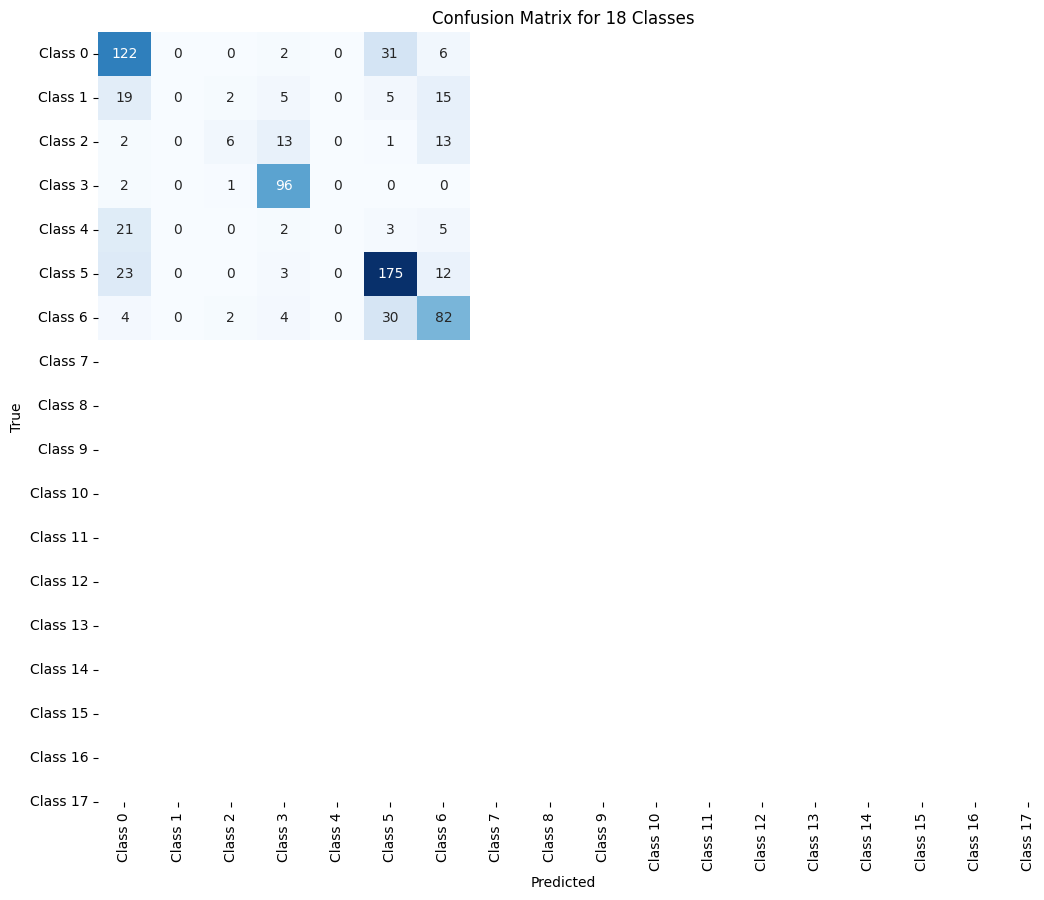

F1 Score (Macro): 0.4592296219604806
F1 Score (Micro): 0.6803394625176803
Test precision:  0.182
Test recall:  0.188
Test F1 score:  0.179


/home/mccwen/.local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/mccwen/.local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/mccwen/.local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score, precision_recall_curve, precision_score, recall_score
accuracy =accuracy_score(y_test_tensor, predicted_labels)
print(f"Accuracy: {accuracy}")

conf_matrix = confusion_matrix(y_test_tensor, predicted_labels)
#print(f"Confusion Matrix:\n{conf_matrix}")
plt.figure(figsize=(12, 10))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=[f'Class {i}' for i in range(18)],
            yticklabels=[f'Class {i}' for i in range(18)], cbar=False)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for 18 Classes')
plt.xticks(rotation=90)
plt.show()


#report= classification_report(y_test_tensor, predicted_labels)
#print(f"Classification report: {report}")

# Calculate F1 score for multi-class classification with 'weighted' average
f1 = f1_score(y_test_tensor, predicted_labels, average='macro')
print(f"F1 Score (Macro): {f1}")

# Calculate F1 score for multi-class classification with 'micro' average
f1_micro = f1_score(y_test_tensor, predicted_labels, average='micro')
print(f"F1 Score (Micro): {f1_micro}")

precision_macro = precision_score(y_test_tensor, predicted_labels, average='macro', labels=range(18))
recall_macro = recall_score(y_test_tensor, predicted_labels, average='macro', labels=range(18))
f1_macro = f1_score(y_test_tensor, predicted_labels, average='macro', labels=range(18))
print(f"Test precision: {precision_macro: .3f}")
print(f"Test recall: {recall_macro: .3f}")
print(f"Test F1 score: {f1_macro: .3f}")

## Compare the true cell types with the predicted ones on validation data

In [42]:
valid_predicted_labels = predict(model, X_valid_tensor)

In [43]:
accuracy =accuracy_score(y_valid_tensor, valid_predicted_labels)
print(f"Accuracy: {accuracy}")

#conf_matrix = confusion_matrix(y_valid_tensor, valid_predicted_labels)
#print(f"Confusion Matrix:\n{conf_matrix}")

#report= classification_report(y_valid_tensor, valid_predicted_labels)
#print(f"Classification report: {report}")

# Calculate F1 score for multi-class classification with 'weighted' average
f1 = f1_score(y_valid_tensor, valid_predicted_labels, average='macro')
print(f"F1 Score (Macro): {f1}")

# Calculate F1 score for multi-class classification with 'micro' average
f1_micro = f1_score(y_valid_tensor, valid_predicted_labels, average='micro')
print(f"F1 Score (Micro): {f1_micro}")

precision_macro = precision_score(y_valid_tensor, valid_predicted_labels, average='macro', labels=range(18))
recall_macro = recall_score(y_valid_tensor, valid_predicted_labels, average='macro', labels=range(18))
f1_macro = f1_score(y_valid_tensor, valid_predicted_labels, average='macro', labels=range(18))
print(f"Validation precision: {precision_macro: .3f}")
print(f"Validation recall: {recall_macro: .3f}")
print(f"Validation F1 score: {f1_macro: .3f}")

Accuracy: 0.6765676567656765
F1 Score (Macro): 0.45325973285679855
F1 Score (Micro): 0.6765676567656765
Validation precision:  0.171
Validation recall:  0.188
Validation F1 score:  0.176


/home/mccwen/.local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/mccwen/.local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/mccwen/.local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
